# Carregamento dos dados

In [1]:
import os
import copy
import json
import time
import random
from pathlib import Path
#import yaml
import itertools
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


import sys
sys.path.append("C:/Users/loren/GNNGCN-proj/src")

from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )    
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "1980-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-12-31"

c:\Users\loren\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_var_at_stations(ds: xr.Dataset,
                        var_name: str,
                        t1: str,
                        t2: str,
                        stations: dict) -> np.ndarray:
    """
    Extrai a variável `var_name` de um dataset ERA5 nos pontos das estações.
    Retorna array (T, N) com a série temporal diária para cada estação.
    """
    da = ds[var_name].sel(time=slice(t1, t2))                # Recorta o intervalo temporal desejado
 
    # Detecta os nomes das coordenadas espaciais (ERA5 usa latitude/longitude)
    lat_name = "latitude" if "latitude" in da.dims else "lat"   # Nome do eixo de latitude
    lon_name = "longitude" if "longitude" in da.dims else "lon" # Nome do eixo de longitude
 
    series = []                                              # Lista para acumular séries por estação
    for sid, info in stations.items():                       # Itera sobre cada estação no dicionário
        lat, lon = info["lat"], info["lon"]                  # Coordenadas da estação atual
        s = da.sel({lat_name: lat, lon_name: lon},           # Interpolação por vizinho mais próximo
                   method="nearest").values                  # Converte para NumPy
        series.append(s)                                     # Acumula a série da estação
 
    arr = np.stack(series, axis=1)                           # Empilha → shape (T, N)
 
    # Se a série é horária, agrega para diária (média do dia)
    if len(arr) > (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1:
        # Recria com índice temporal e faz resample diário
        time_index = pd.to_datetime(da["time"].values)       # Índice de tempo do xarray
        df = pd.DataFrame(arr, index=time_index)             # DataFrame para usar resample
        arr = df.resample("D").mean().values                 # Média diária por estação
 
    return arr.astype(np.float32)                            # Retorna como float32

In [3]:
catalog_dir = Path("C:/Users/loren/GNNGCN-proj") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

estacoes = list(estacoes_RS.keys())
print(f"Estação no índice 32: {estacoes[32]}")
print(f"Coordenadas: {estacoes_RS[estacoes[32]]}")

Estação no índice 32: PORTO ALEGRE - JARDIM BOTANICO
Coordenadas: ['-30.05361111', '-51.17472221']


In [4]:
base = "C:/Users/loren/GNNGCN-proj"
nc_dir = os.path.join(base, "Datasets", "nc_files")          # Pasta com os arquivos NetCDF
 
start_date = "2024-01-01"                                    # Início do período
end_date   = "2025-12-31"                                    # Fim do período
 
# Carrega os três datasets (precipitação, temperatura, umidade/orvalho)
rea_tp = xr.open_dataset(os.path.join(nc_dir, "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))   # Precipitação
rea_temp  = xr.open_dataset(os.path.join(nc_dir, "temp_05-25.nc")).sel(time=slice(start_date, end_date))     # Temperatura 2m (t2m)
rea_vv = xr.open_dataset(os.path.join(nc_dir, "era5_vv_06-25.nc")).sel(time=slice(start_date, end_date))        # Vertical Velocity
 
T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1   # Total de dias
N = len(estacoes_RS)                                                    # Total de estações
 
 

In [5]:
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

In [6]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

In [7]:
# Itera sobre os valores e converte string -> float
coords = np.array([[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
                  dtype=np.float64)
nomes = list(estacoes_RS.keys())   # guarde se quiser saber qual nó é qual estação
N = coords.shape[0]

In [27]:
k = 2

# Matriz de adjacências dos vizinhos

In [28]:
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]

# Cria uma matriz N x N preenchida com zeros
A = np.zeros((N, N), dtype=np.float32)

# Para cada nó i, marca como 1 a posição dos seus k vizinhos mais próximos.
# A[i, idx[i]] = 1.0 indica "existe aresta de i para cada vizinho na lista idx[i]".
# Note: nesse passo, A ainda é direcional (i -> j não implica j -> i).
for i in range(N):
    A[i, idx[i]] = 1.0

# Torna a matriz simétrica via "OU" entre A e sua transposta.
# np.maximum(A, A.T) garante que se i é vizinho de j OU j é vizinho de i, a aresta existe nos dois sentidos.
# Isso transforma o grafo k-NN direcionado em um grafo não-direcionado (vizinhança mútua).
A = np.maximum(A, A.T)

# Adiciona self-loops (cada nó conectado a si mesmo) somando a matriz identidade.
# Self-loops fazem com que, na agregação A @ X, cada nó preserve suas próprias features
# junto com as dos vizinhos, em vez de ser substituído apenas pela média da vizinhança.
A = A + np.eye(N, dtype=np.float32)

# Agregação por média

# Calcula o grau de cada nó (soma das conexões na linha) — quantos vizinhos cada um tem (incluindo self-loop).
# keepdims=True mantém shape (N, 1) para permitir broadcasting na divisão linha a linha.
deg = A.sum(axis=1, keepdims=True)

# Divide cada linha de A pelo grau correspondente, transformando soma em média.
# Resultado: cada linha de A_norm soma 1 — agregação vira "média das features dos vizinhos".
A_norm = torch.tensor(A / deg, dtype=torch.float32) 

In [29]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


target_date = "2024-05-04"
n_idx = 32 # ID da estação (32 - Porto Alegre, Jardim Botânico)
F_in  = 2 # F_in é a dimensão das features de entrada. Como estamos tratando 
          # de umidade e velocidade vertical, a dimensão é 2.
epochs = 200 # Épocas
hidden = 2 # Número de neurônios na camada oculta
lr = 1e-3 # Taxa de aprendizado "eta".

# Proporções do split (por nós)
p_train = 0.70
p_val   = 0.10
p_test  = 0.20  # implícito: 1 - p_train - p_val

# =====================================================
# 2) Monta entrada e target para o dia alvo
# =====================================================
t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

vv_t = X_vv[t_idx, :, 0]
t_t  = X_t [t_idx, :, 0]
X_in = torch.stack([vv_t, t_t], dim=-1).float()   # (N, 2)

y_all = X_tp[t_idx, :, 0].float()                 # (N,)

N = X_in.shape[0]   # nº total de nós

# =====================================================
# 2.1) Split por nós: treino / validação / teste
# =====================================================
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)

n_train = int(round(p_train * N))
n_val   = int(round(p_val   * N))
n_test  = N - n_train - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val:]

def make_mask(indices, N):
    m = torch.zeros(N, dtype=torch.bool)
    m[indices] = True
    return m

mask_train = make_mask(idx_train, N)
mask_val   = make_mask(idx_val,   N)
mask_test  = make_mask(idx_test,  N)

print(f"Total de nós: {N}")
print(f"  Treino: {mask_train.sum().item()}  "
      f"Val: {mask_val.sum().item()}  "
      f"Teste: {mask_test.sum().item()}")

Total de nós: 62
  Treino: 43  Val: 6  Teste: 13


# Montagem do grafo

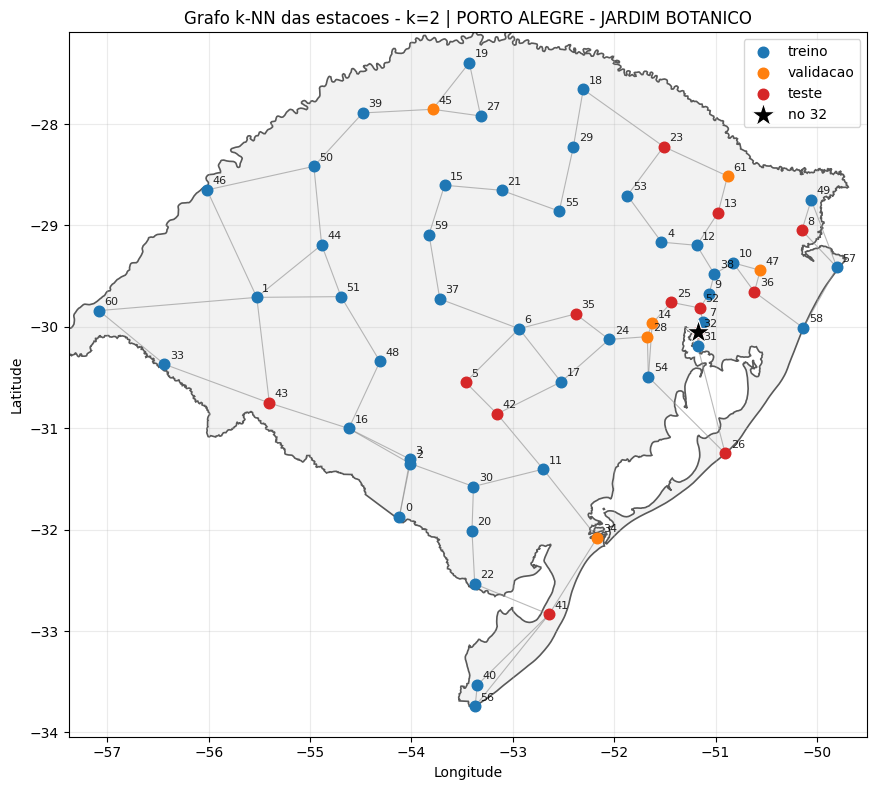

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=2:
  no   7 -> CACHOEIRINHA
  no  31 -> PORTO ALEGRE - BELEM NOVO


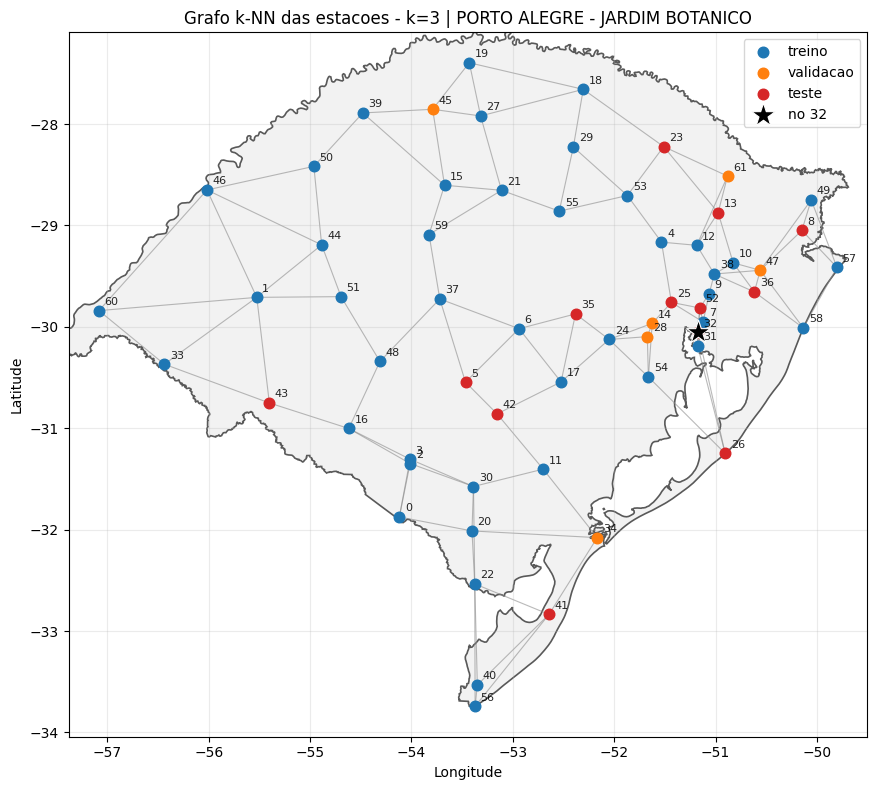

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=3:
  no   7 -> CACHOEIRINHA
  no  26 -> MOSTARDAS
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  52 -> SAPUCAIA DO SUL


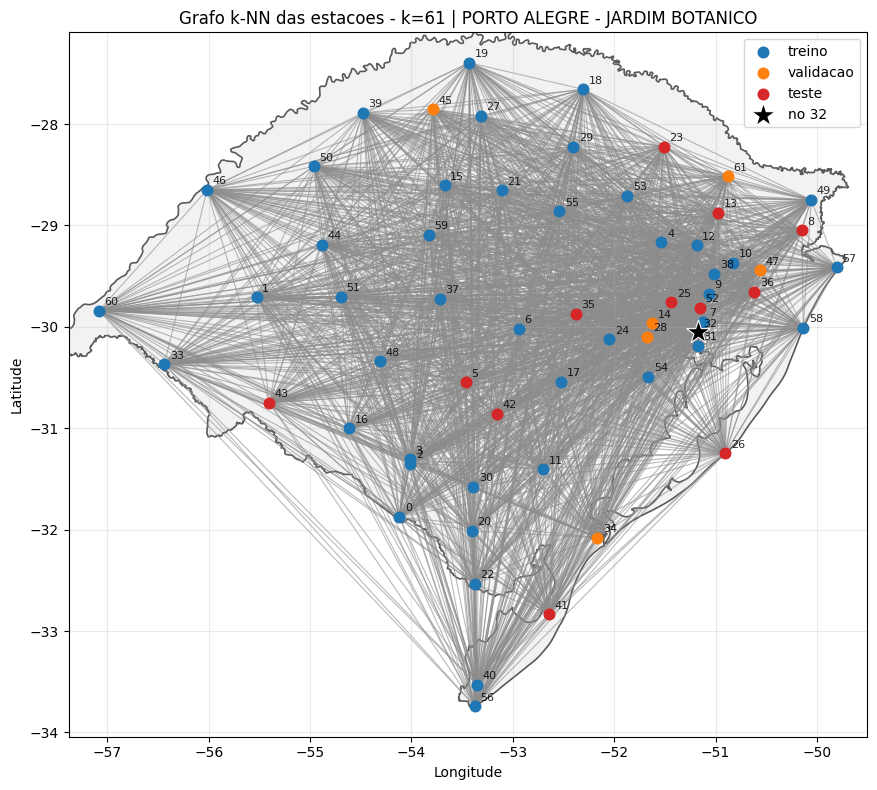

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=61:
  no   0 -> ACEGUA
  no   1 -> ALEGRETE
  no   2 -> BAGE
  no   3 -> BAGE - CENTRO
  no   4 -> BENTO GONCALVES
  no   5 -> CACAPAVA DO SUL
  no   6 -> CACHOEIRA DO SUL
  no   7 -> CACHOEIRINHA
  no   8 -> CAMBARA DO SUL
  no   9 -> CAMPO BOM
  no  10 -> CANELA
  no  11 -> CANGUCU
  no  12 -> CAXIAS DO SUL - AEROPORTO
  no  13 -> CAXIAS DO SUL - CRIUVA
  no  14 -> CHARQUEADAS
  no  15 -> CRUZ ALTA
  no  16 -> DOM PEDRITO
  no  17 -> ENCRUZILHADA DO SUL
  no  18 -> ERECHIM
  no  19 -> FREDERICO WESTPHALEN
  no  20 -> HERVAL
  no  21 -> IBIRUBA
  no  22 -> JAGUARAO
  no  23 -> LAGOA VERMELHA
  no  24 -> MINAS DO LEAO
  no  25 -> MONTENEGRO
  no  26 -> MOSTARDAS
  no  27 -> PALMEIRA DAS MISSOES
  no  28 -> PARQUE ELDORADO
  no  29 -> PASSO FUNDO
  no  30 -> PINHEIRO MACHADO
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  33 -> QUARAI
  no  34 -> RIO GRANDE
  no  35 -> RIO PARDO
  no  36 -> ROLANTE
  no  37 -> SANTA MARIA
  n

In [30]:
import json
import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

n_idx = 32  # Índice do nó para destacar (estação no índice 32)

def carregar_mapa_rs_ibge():
    url = "https://servicodados.ibge.gov.br/api/v3/malhas/estados/43?formato=application/vnd.geo+json"

    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json, application/geo+json",
            "Accept-Encoding": "identity",
        }
    )

    with urllib.request.urlopen(req) as resposta:
        dados = resposta.read()

    # Se vier compactado em gzip, descompacta antes de decodificar
    if dados[:2] == b"\x1f\x8b":
        dados = gzip.decompress(dados)

    return json.loads(dados.decode("utf-8"))


def plot_geojson(ax, geojson, facecolor="#f2f2f2", edgecolor="0.35", linewidth=1.2):
    for feature in geojson["features"]:
        geom = feature["geometry"]

        if geom["type"] == "Polygon":
            polygons = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            polygons = geom["coordinates"]
        else:
            continue

        for polygon in polygons:
            exterior = polygon[0]
            lons = [p[0] for p in exterior]
            lats = [p[1] for p in exterior]

            ax.fill(
                lons,
                lats,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=0
            )


def build_adjacency(coords, k=2, include_self=False):
    coords = np.asarray(coords, dtype=float)
    N = coords.shape[0]

    if k >= N:
        raise ValueError(f"k={k} precisa ser menor que o numero de nos N={N}.")

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nbrs.kneighbors(coords)
    idx = idx[:, 1:]

    A_bin = np.zeros((N, N), dtype=bool)

    for i in range(N):
        A_bin[i, idx[i]] = True

    A_bin = A_bin | A_bin.T

    if include_self:
        np.fill_diagonal(A_bin, True)
    else:
        np.fill_diagonal(A_bin, False)

    return A_bin


def as_numpy_mask(mask):
    if hasattr(mask, "detach"):
        return mask.detach().cpu().numpy().astype(bool)
    return np.asarray(mask, dtype=bool)


def plot_knn_graph(coords, k=2, n_idx=32, nomes=None,
                   mask_train=None, mask_val=None, mask_test=None,
                   figsize=(11, 8), label_nodes=True,
                   mapa_rs=None):

    coords = np.asarray(coords, dtype=float)
    A_bin = build_adjacency(coords, k=k, include_self=False)
    N = coords.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    if mapa_rs is not None:
        plot_geojson(ax, mapa_rs)

    for i in range(N):
        for j in range(i + 1, N):
            if A_bin[i, j]:
                ax.plot(
                    [coords[i, 1], coords[j, 1]],
                    [coords[i, 0], coords[j, 0]],
                    color="0.55",
                    linewidth=0.8,
                    alpha=0.6,
                    zorder=1,
                )

    if mask_train is not None and mask_val is not None and mask_test is not None:
        train = as_numpy_mask(mask_train)
        val = as_numpy_mask(mask_val)
        test = as_numpy_mask(mask_test)

        ax.scatter(coords[train, 1], coords[train, 0], s=58, c="tab:blue", label="treino", zorder=3)
        ax.scatter(coords[val, 1], coords[val, 0], s=58, c="tab:orange", label="validacao", zorder=3)
        ax.scatter(coords[test, 1], coords[test, 0], s=58, c="tab:red", label="teste", zorder=3)
    else:
        ax.scatter(coords[:, 1], coords[:, 0], s=58, c="tab:blue", label="estacoes", zorder=3)

    ax.scatter(
        coords[n_idx, 1],
        coords[n_idx, 0],
        s=320,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        label=f"no {n_idx}",
        zorder=5,
    )

    if label_nodes:
        for i in range(N):
            ax.annotate(
                str(i),
                (coords[i, 1], coords[i, 0]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.85,
                zorder=6,
            )

    vizinhos = np.where(A_bin[n_idx])[0]
    nome_no = nomes[n_idx] if nomes is not None else f"no {n_idx}"

    lon = coords[:, 1]
    lat = coords[:, 0]

    ax.set_xlim(lon.min() - 0.3, lon.max() + 0.3)
    ax.set_ylim(lat.min() - 0.3, lat.max() + 0.3)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"Grafo k-NN das estacoes - k={k} | {nome_no}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Vizinhos diretos do no {n_idx} ({nome_no}) para k={k}:")
    for j in vizinhos:
        nome_vizinho = nomes[j] if nomes is not None else f"no {j}"
        print(f"  no {j:3d} -> {nome_vizinho}")

    return A_bin


mapa_rs = carregar_mapa_rs_ibge()

A_grafo2 = plot_knn_graph(coords, k=2, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo3 = plot_knn_graph(coords, k=3, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo61 = plot_knn_graph(coords, k=61, n_idx=n_idx, nomes=nomes,
                           mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                           figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

In [31]:
n_hidden_layers = 2

# Matriz com pesos nas arestas


In [32]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def normalize_weighted_adjacency(A, eps=1e-12):
    if not torch.is_tensor(A):
        A = torch.tensor(A, dtype=torch.float32)
    else:
        A = A.float()

    degree = A.sum(dim=1, keepdim=True).clamp_min(eps)
    return A / degree


def make_weighted_adjacency_from_binary(
    A_base,
    edge_weights=None,
    default_edge_weight=1.0,
    self_loop_weight=1.0,
    symmetric=True,
    allow_new_edges=False,
    dtype=torch.float32,
    device=None,
):
    if torch.is_tensor(A_base):
        if device is None:
            device = A_base.device
        A_np = A_base.detach().cpu().numpy()
    else:
        A_np = np.asarray(A_base)

    N = A_np.shape[0]

    topology = A_np > 0
    np.fill_diagonal(topology, False)

    if symmetric:
        topology = topology | topology.T

    A_weighted_np = np.zeros((N, N), dtype=np.float32)
    A_weighted_np[topology] = float(default_edge_weight)

    edge_weights = edge_weights or {}

    for (i, j), weight in edge_weights.items():
        i = int(i)
        j = int(j)
        weight = float(weight)

        if weight < 0:
            raise ValueError(f"Peso negativo nao permitido: ({i}, {j}) = {weight}")

        edge_exists = bool(topology[i, j] or (symmetric and topology[j, i]))

        if i != j and not edge_exists and not allow_new_edges:
            raise ValueError(
                f"A aresta ({i}, {j}) nao existe em A_base. "
                "Use allow_new_edges=True para cria-la."
            )

        A_weighted_np[i, j] = weight

        if symmetric:
            A_weighted_np[j, i] = weight

    np.fill_diagonal(A_weighted_np, float(self_loop_weight))

    if device is None:
        A_weighted = torch.tensor(A_weighted_np, dtype=dtype)
    else:
        A_weighted = torch.tensor(A_weighted_np, dtype=dtype, device=device)

    A_norm_weighted = normalize_weighted_adjacency(A_weighted)

    return A_weighted, A_norm_weighted

In [33]:
# =====================================================
# Pesos das arestas: exp(-||x_i - x_j||)
# =====================================================

coords_tensor = torch.tensor(coords, dtype=torch.float32)

# Matriz de distancias euclidianas entre todos os nos
dist_matrix = torch.cdist(coords_tensor, coords_tensor, p=2)

# Mascara das arestas existentes no grafo A
edge_mask = torch.tensor(A, dtype=torch.float32) > 0
edge_mask.fill_diagonal_(False)

# Peso de cada aresta existente: e^(-distancia)
edge_weight_matrix = torch.exp(-dist_matrix)

edge_weights = {
    (int(i), int(j)): float(edge_weight_matrix[i, j])
    for i, j in edge_mask.nonzero(as_tuple=False)
}

In [34]:
A_weighted, A_norm_weighted = make_weighted_adjacency_from_binary(
    A_base=A,
    edge_weights=edge_weights,
    default_edge_weight=1.0,
    self_loop_weight=1.0,
    symmetric=True,
    allow_new_edges=False,
)

A_norm = A_norm_weighted


# =====================================================
# Modelo GNN com arestas ponderadas
# =====================================================

class WeightedGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_hidden_layers=6, out_dim=1):
        super().__init__()

        self.hidden_layers = nn.ModuleList()
        self.hidden_layers.append(nn.Linear(in_dim, hidden_dim))

        for _ in range(n_hidden_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))

        self.W_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, X, A_norm_weighted):
        H = X

        for layer in self.hidden_layers:
            H = A_norm_weighted @ H
            H = F.relu(layer(H))

        out = self.W_out(H)
        return out.squeeze(-1)


modelo = WeightedGNN(
    in_dim=F_in,
    hidden_dim=hidden,
    n_hidden_layers=n_hidden_layers,
)

otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
loss_fn = nn.MSELoss()

print("A_weighted shape:", tuple(A_weighted.shape))
print("A_norm_weighted shape:", tuple(A_norm_weighted.shape))
print("Soma das primeiras linhas:", A_norm_weighted.sum(dim=1)[:5])

A_weighted shape: (62, 62)
A_norm_weighted shape: (62, 62)
Soma das primeiras linhas: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [52]:
from pathlib import Path
import numpy as np
import pandas as pd


def build_edge_weights_table(A_weighted, A_norm_weighted=None, nomes=None, directed=False):
    if hasattr(A_weighted, "detach"):
        W = A_weighted.detach().cpu().numpy()
    else:
        W = np.asarray(A_weighted, dtype=float)

    if A_norm_weighted is not None:
        if hasattr(A_norm_weighted, "detach"):
            W_norm = A_norm_weighted.detach().cpu().numpy()
        else:
            W_norm = np.asarray(A_norm_weighted, dtype=float)
    else:
        W_norm = None

    rows = []
    N = W.shape[0]

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            if not directed and i > j:
                continue

            if W[i, j] <= 0:
                continue

            row = {
                "no_i": i,
                "no_j": j,
                "peso_bruto": W[i, j],
            }

            if nomes is not None:
                row["estacao_i"] = nomes[i]
                row["estacao_j"] = nomes[j]

            if W_norm is not None:
                row["peso_normalizado_i_para_j"] = W_norm[i, j]

                if not directed:
                    row["peso_normalizado_j_para_i"] = W_norm[j, i]

            rows.append(row)

    df_weights = pd.DataFrame(rows)

    if not df_weights.empty:
        df_weights = df_weights.sort_values(
            ["no_i", "no_j"],
            ascending=True
        ).reset_index(drop=True)

    return df_weights

df_edge_weights = build_edge_weights_table(
    A_weighted=A_weighted,
    A_norm_weighted=A_norm_weighted,
    nomes=nomes,
    directed=False,
)

display(df_edge_weights)

,no_i,no_j,peso_bruto,estacao_i,estacao_j,peso_normalizado_i_para_j,peso_normalizado_j_para_i
0,0,2,0.584122,ACEGUA,BAGE,0.272384,0.164379
1,0,3,0.560358,ACEGUA,BAGE - CENTRO,0.261302,0.185207
2,1,43,0.350420,ALEGRETE,SANTANA DO LIVRAMENTO,0.127602,0.165196
3,1,44,0.439134,ALEGRETE,SANTIAGO,0.159907,0.177209
4,1,46,0.311244,ALEGRETE,SAO BORJA,0.113337,0.188504
...,...,...,...,...,...,...,...
74,44,51,0.579662,SANTIAGO,SAO VICENTE DO SUL,0.233917,0.232811
75,46,50,0.339887,SAO BORJA,SAO LUIZ GONZAGA,0.205851,0.148502
76,48,51,0.474531,SAO GABRIEL,SAO VICENTE DO SUL,0.242471,0.190587
77,49,57,0.490783,SAO JOSE DOS AUSENTES,TORRES,0.220948,0.188693


In [40]:
import copy
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def run_experiment_weighted(epochs, hidden, n_hidden_layers, X_in, y_all, A_norm_weighted,
                            mask_train, mask_val, mask_test,
                            F_in=2, lr=1e-3, n_idx=32, seed=42,
                            patience=20, min_delta=1e-5):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    modelo = WeightedGNN(
        in_dim=F_in,
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers
    )

    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    historico = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
    }

    best_val = float("inf")
    best_epoch = 0
    stop_epoch = epochs
    patience_count = 0
    best_state = copy.deepcopy(modelo.state_dict())

    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()

        y_pred_all = modelo(X_in, A_norm_weighted)
        loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])

        loss_train.backward()
        otimizador.step()

        modelo.eval()
        with torch.no_grad():
            y_pred_eval = modelo(X_in, A_norm_weighted)
            loss_val = loss_fn(y_pred_eval[mask_val], y_all[mask_val])
            loss_test = loss_fn(y_pred_eval[mask_test], y_all[mask_test])

        historico["train_loss"].append(loss_train.item())
        historico["val_loss"].append(loss_val.item())
        historico["test_loss"].append(loss_test.item())

        if loss_val.item() < best_val - min_delta:
            best_val = loss_val.item()
            best_epoch = epoca
            best_state = copy.deepcopy(modelo.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            stop_epoch = epoca
            break

    modelo.load_state_dict(best_state)

    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_norm_weighted)

        loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
        loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
        loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()
        pred_no      = y_pred_all[n_idx].item()
        true_no      = y_all[n_idx].item()

    return {
        "epochs": epochs,
        "hidden": hidden,
        "n_hidden_layers": n_hidden_layers,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "loss_train": loss_train_f,
        "loss_val": loss_val_f,
        "loss_test": loss_test_f,
        "pred": pred_no,
        "true": true_no,
        "historico": historico,
    }


epochs_grid = [100, 200, 400, 500, 1000]
hidden_grid = [2, 6, 12, 24]

resultados_weighted = []
historicos_weighted = {}
paradas_weighted = {}

for ep, hd in itertools.product(epochs_grid, hidden_grid):
    print(f"Rodando Weighted GNN epochs={ep}, hidden={hd}...")

    r = run_experiment_weighted(
        epochs=ep,
        hidden=hd,
        n_hidden_layers=n_hidden_layers,
        X_in=X_in,
        y_all=y_all,
        A_norm_weighted=A_norm_weighted,
        mask_train=mask_train,
        mask_val=mask_val,
        mask_test=mask_test,
        F_in=F_in,
        lr=lr,
        n_idx=n_idx,
        seed=SEED,
        patience=60,
        min_delta=1e-4
    )

    historicos_weighted[(ep, hd)] = r["historico"]
    paradas_weighted[(ep, hd)] = r["stop_epoch"]

    r_sem_historico = r.copy()
    del r_sem_historico["historico"]
    resultados_weighted.append(r_sem_historico)

df_weighted = pd.DataFrame(resultados_weighted)
print(df_weighted)

output_dir = Path("../Results_WGNN")
output_dir.mkdir(parents=True, exist_ok=True)

target_date_file = target_date.replace("-", "")
nome_arquivo = f"WeightedGNNResults-K{k}-HL{n_hidden_layers}-D{target_date_file}.csv"
nome_arquivo_tex = f"WeightedGNNResults-K{k}-HL{n_hidden_layers}-D{target_date_file}.tex"
output_path = output_dir / nome_arquivo
output_tex_path = output_dir / nome_arquivo_tex

df_weighted.to_csv(output_path, index=False)
df_weighted.to_latex(
    output_tex_path,
    index=False,
    float_format="%.6f",
    caption="Resultados da Weighted GNN",
    label="tab:weighted_gnn_results",
    escape=True,
)

print(f"Arquivo CSV salvo em: {output_path}")
print(f"Arquivo TeX salvo em: {output_tex_path}")

Rodando Weighted GNN epochs=100, hidden=2...
Rodando Weighted GNN epochs=100, hidden=6...
Rodando Weighted GNN epochs=100, hidden=12...
Rodando Weighted GNN epochs=100, hidden=24...
Rodando Weighted GNN epochs=200, hidden=2...
Rodando Weighted GNN epochs=200, hidden=6...
Rodando Weighted GNN epochs=200, hidden=12...
Rodando Weighted GNN epochs=200, hidden=24...
Rodando Weighted GNN epochs=400, hidden=2...
Rodando Weighted GNN epochs=400, hidden=6...
Rodando Weighted GNN epochs=400, hidden=12...
Rodando Weighted GNN epochs=400, hidden=24...
Rodando Weighted GNN epochs=500, hidden=2...
Rodando Weighted GNN epochs=500, hidden=6...
Rodando Weighted GNN epochs=500, hidden=12...
Rodando Weighted GNN epochs=500, hidden=24...
Rodando Weighted GNN epochs=1000, hidden=2...
Rodando Weighted GNN epochs=1000, hidden=6...
Rodando Weighted GNN epochs=1000, hidden=12...
Rodando Weighted GNN epochs=1000, hidden=24...
    epochs  hidden  n_hidden_layers  best_epoch  stop_epoch   loss_train  \
0      100

Grafico salvo em: ..\Graphics_WGNN\WeightedGNNGraphics-K2-HL2-D20240504.png


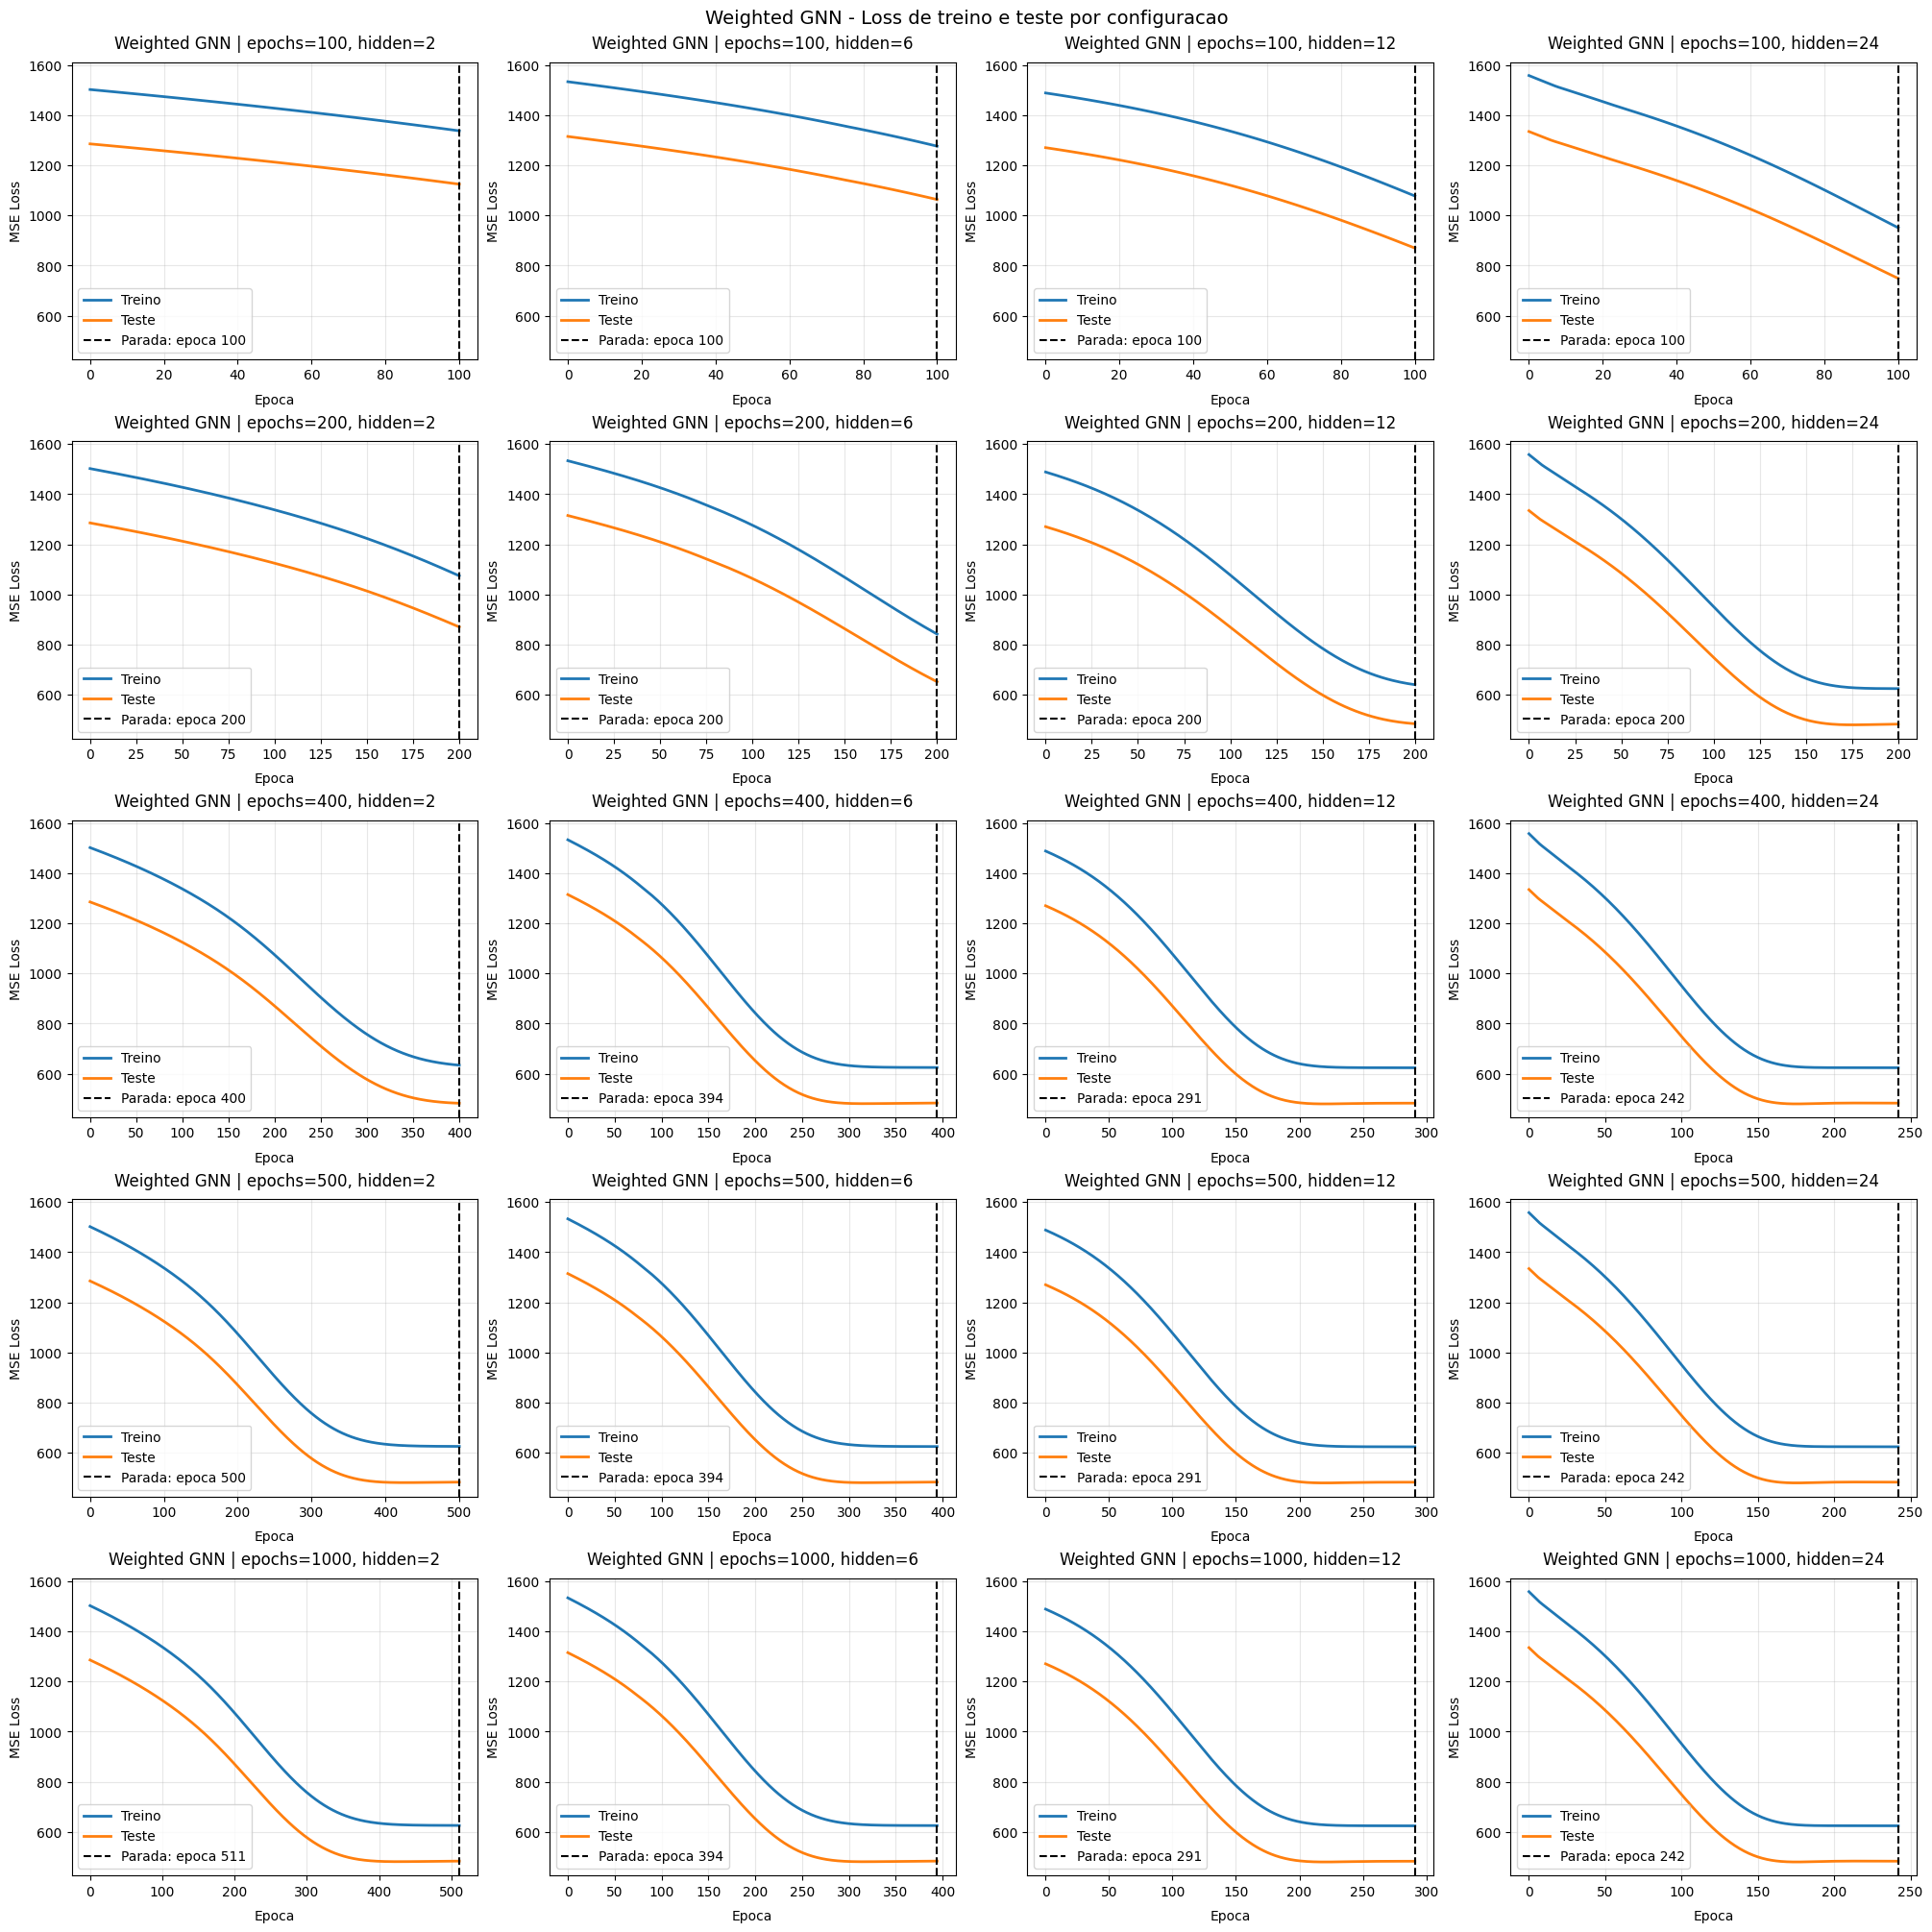

In [41]:
n_linhas = len(epochs_grid)
n_colunas = len(hidden_grid)

todos_losses = []

for ep in epochs_grid:
    for hd in hidden_grid:
        hist = historicos_weighted[(ep, hd)]
        todos_losses.extend(hist["train_loss"])
        todos_losses.extend(hist["test_loss"])

y_min = min(todos_losses)
y_max = max(todos_losses)

margem = 0.05 * (y_max - y_min)

if margem == 0:
    margem = 1

y_min -= margem
y_max += margem

fig, axes = plt.subplots(
    n_linhas,
    n_colunas,
    figsize=(5 * n_colunas, 4 * n_linhas),
    sharey=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(n_linhas, n_colunas)

for i, ep in enumerate(epochs_grid):
    for j, hd in enumerate(hidden_grid):
        ax = axes[i, j]

        hist = historicos_weighted[(ep, hd)]
        epocas = range(len(hist["train_loss"]))

        ax.plot(epocas, hist["train_loss"], label="Treino", color="tab:blue", linewidth=2)
        ax.plot(epocas, hist["test_loss"], label="Teste", color="tab:orange", linewidth=2)

        stop_epoch = paradas_weighted[(ep, hd)]

        ax.axvline(
            stop_epoch,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Parada: epoca {stop_epoch}"
        )

        ax.set_title(f"Weighted GNN | epochs={ep}, hidden={hd}", pad=10)
        ax.set_xlabel("Epoca", labelpad=8)
        ax.set_ylabel("MSE Loss")
        ax.set_ylim(y_min, y_max)
        ax.tick_params(axis="y", labelleft=True)
        ax.grid(alpha=0.3)
        ax.legend(loc="best")

fig.suptitle("Weighted GNN - Loss de treino e teste por configuracao", fontsize=14)

graphics_dir = Path("../Graphics_WGNN")
graphics_dir.mkdir(parents=True, exist_ok=True)

nome_imagem = f"WeightedGNNGraphics-K{k}-HL{n_hidden_layers}-D{target_date_file}.png"
output_path = graphics_dir / nome_imagem

fig.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"Grafico salvo em: {output_path}")

plt.show()

Grafo salvo em: ..\Grafos\WeightedGraphMapRS-K2-D20240504.png


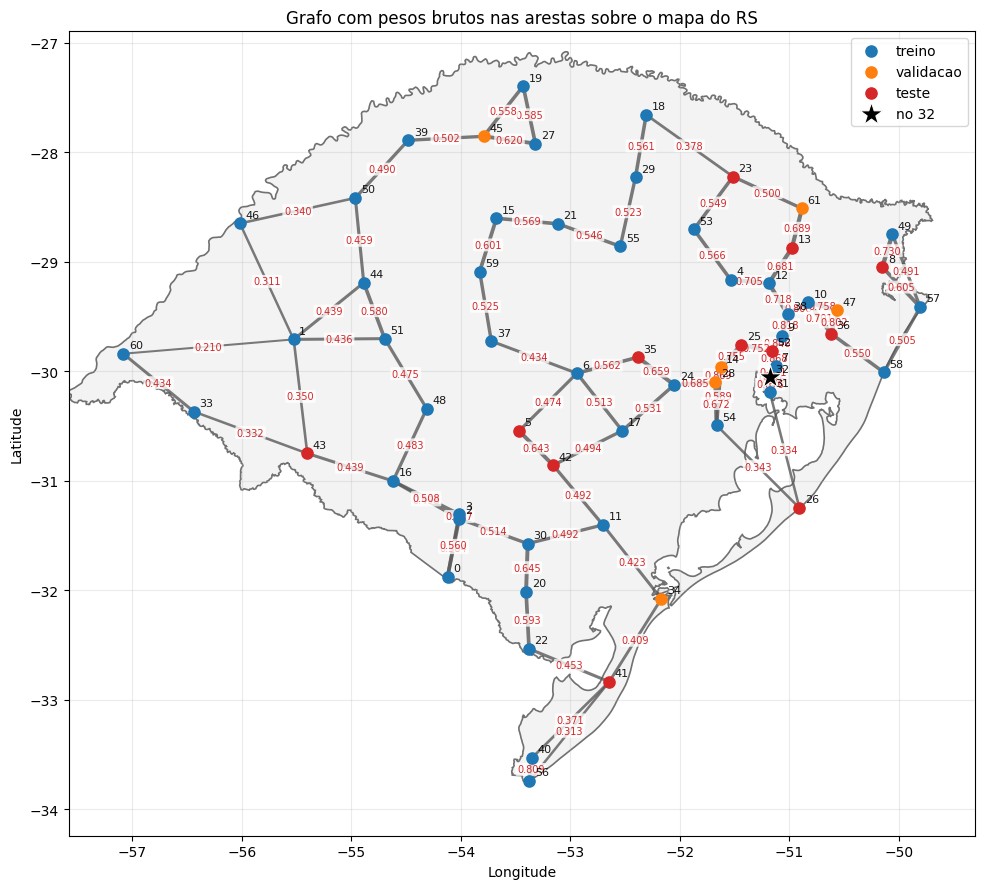

In [48]:
from pathlib import Path
import json
import gzip
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def carregar_mapa_rs_ibge():
    url = "https://servicodados.ibge.gov.br/api/v3/malhas/estados/43?formato=application/vnd.geo+json"

    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json, application/geo+json",
            "Accept-Encoding": "identity",
        },
    )

    with urllib.request.urlopen(req) as resposta:
        dados = resposta.read()

    if dados[:2] == b"\x1f\x8b":
        dados = gzip.decompress(dados)

    return json.loads(dados.decode("utf-8"))


def plot_geojson_rs(ax, geojson, facecolor="#f2f2f2", edgecolor="0.35", linewidth=1.2, alpha=0.85):
    for feature in geojson["features"]:
        geom = feature["geometry"]

        if geom["type"] == "Polygon":
            polygons = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            polygons = geom["coordinates"]
        else:
            continue

        for polygon in polygons:
            exterior = polygon[0]
            lons = [p[0] for p in exterior]
            lats = [p[1] for p in exterior]

            ax.fill(
                lons,
                lats,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
                zorder=0,
            )


def plot_weighted_graph(
    coords,
    A_weighted,
    mapa_rs=None,
    nomes=None,
    n_idx=None,
    mask_train=None,
    mask_val=None,
    mask_test=None,
    decimals=3,
    weight_label_color="tab:red",
    figsize=(12, 9),
    title="Grafo com pesos nas arestas",
    save_path=None,
):
    coords_np = np.asarray(coords, dtype=float)

    if hasattr(A_weighted, "detach"):
        W = A_weighted.detach().cpu().numpy()
    else:
        W = np.asarray(A_weighted, dtype=float)

    N = W.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    if mapa_rs is not None:
        plot_geojson_rs(ax, mapa_rs)

    edge_values = []

    for i in range(N):
        for j in range(i + 1, N):
            if W[i, j] > 0:
                edge_values.append(W[i, j])

    max_weight = max(edge_values) if edge_values else 1.0

    for i in range(N):
        for j in range(i + 1, N):
            weight = W[i, j]

            if weight <= 0:
                continue

            x_i, y_i = coords_np[i, 1], coords_np[i, 0]
            x_j, y_j = coords_np[j, 1], coords_np[j, 0]

            linewidth = 0.8 + 3.0 * (weight / max_weight)

            ax.plot(
                [x_i, x_j],
                [y_i, y_j],
                color="0.35",
                linewidth=linewidth,
                alpha=0.8,
                zorder=2,
            )

            mid_x = (x_i + x_j) / 2
            mid_y = (y_i + y_j) / 2

            ax.text(
                mid_x,
                mid_y,
                f"{weight:.{decimals}f}",
                fontsize=7,
                color=weight_label_color,
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                ),
                zorder=4,
            )

    if mask_train is not None and mask_val is not None and mask_test is not None:
        train = mask_train.detach().cpu().numpy().astype(bool)
        val = mask_val.detach().cpu().numpy().astype(bool)
        test = mask_test.detach().cpu().numpy().astype(bool)

        ax.scatter(coords_np[train, 1], coords_np[train, 0], s=65, c="tab:blue", label="treino", zorder=5)
        ax.scatter(coords_np[val, 1], coords_np[val, 0], s=65, c="tab:orange", label="validacao", zorder=5)
        ax.scatter(coords_np[test, 1], coords_np[test, 0], s=65, c="tab:red", label="teste", zorder=5)
    else:
        ax.scatter(coords_np[:, 1], coords_np[:, 0], s=65, c="tab:blue", label="estacoes", zorder=5)

    if n_idx is not None:
        ax.scatter(
            coords_np[n_idx, 1],
            coords_np[n_idx, 0],
            s=300,
            marker="*",
            c="black",
            edgecolors="white",
            linewidths=0.8,
            label=f"no {n_idx}",
            zorder=6,
        )

    for i in range(N):
        ax.annotate(
            str(i),
            (coords_np[i, 1], coords_np[i, 0]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.9,
            zorder=7,
        )

    lon = coords_np[:, 1]
    lat = coords_np[:, 0]

    ax.set_xlim(lon.min() - 0.5, lon.max() + 0.5)
    ax.set_ylim(lat.min() - 0.5, lat.max() + 0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25, zorder=1)
    ax.legend(loc="best")
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Grafo salvo em: {save_path}")

    return fig, ax


def build_edge_weights_table(A_weighted, A_norm_weighted=None, nomes=None):
    if hasattr(A_weighted, "detach"):
        W = A_weighted.detach().cpu().numpy()
    else:
        W = np.asarray(A_weighted, dtype=float)

    if A_norm_weighted is not None:
        if hasattr(A_norm_weighted, "detach"):
            W_norm = A_norm_weighted.detach().cpu().numpy()
        else:
            W_norm = np.asarray(A_norm_weighted, dtype=float)
    else:
        W_norm = None

    rows = []
    N = W.shape[0]

    for i in range(N):
        for j in range(i + 1, N):
            if W[i, j] <= 0:
                continue

            row = {
                "no_i": i,
                "no_j": j,
                "peso_bruto": W[i, j],
            }

            if nomes is not None:
                row["estacao_i"] = nomes[i]
                row["estacao_j"] = nomes[j]

            if W_norm is not None:
                row["peso_normalizado_i_para_j"] = W_norm[i, j]
                row["peso_normalizado_j_para_i"] = W_norm[j, i]

            rows.append(row)

    df_weights = pd.DataFrame(rows)

    if not df_weights.empty:
        df_weights = df_weights.sort_values("peso_bruto", ascending=False).reset_index(drop=True)

    return df_weights


if "mapa_rs" not in globals():
    mapa_rs = carregar_mapa_rs_ibge()

target_date_file = target_date.replace("-", "") if "target_date" in globals() else "sem_data"
k_file = k if "k" in globals() else "NA"

fig, ax = plot_weighted_graph(
    coords=coords,
    A_weighted=A_weighted,
    mapa_rs=mapa_rs,
    n_idx=n_idx if "n_idx" in globals() else None,
    mask_train=mask_train if "mask_train" in globals() else None,
    mask_val=mask_val if "mask_val" in globals() else None,
    mask_test=mask_test if "mask_test" in globals() else None,
    decimals=3,
    weight_label_color="tab:red",
    title="Grafo com pesos brutos nas arestas sobre o mapa do RS",
    save_path=Path("../Grafos") / f"WeightedGraphMapRS-K{k_file}-D{target_date_file}.png",
)

plt.show()